<a href="https://colab.research.google.com/github/leenmahmoud201/Final_reoprt_AI/blob/main/Entier_code_group_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Fetal Health Classification & Body Fat Regression

## Final Project: AI Classification & Regression
**Course:** CS362 - Artificial Intelligence  
**Phase:** Phase One

### Team Members:
* **Name:** Leen Mahmoud
* **Student ID:** 165930

In [1]:
#google_drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Step 0: Imports and Reading Data

In [2]:
#import_Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor,
                               VotingClassifier, VotingRegressor,
                               StackingClassifier, StackingRegressor)
from sklearn.svm import SVC, SVR
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline


plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
#Load Datasets
df_fetal = pd.read_csv('/content/drive/My Drive/Fetal Health Classification/fetal_health.csv')
df_bodyfat= pd.read_csv('/content/drive/My Drive/Body Fat Prediction Dataset/bodyfat.csv')
print("Fetal Health shape:", df_fetal.shape)
print("Body Fat shape:", df_bodyfat.shape)

Fetal Health shape: (2126, 22)
Body Fat shape: (252, 15)


##Step 1: Data Understanding

# 1. Fetal Health Analysis (Classification)

Fetal Health Summary Statistics:
(2126, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000



Missing values in Fetal Health:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogr

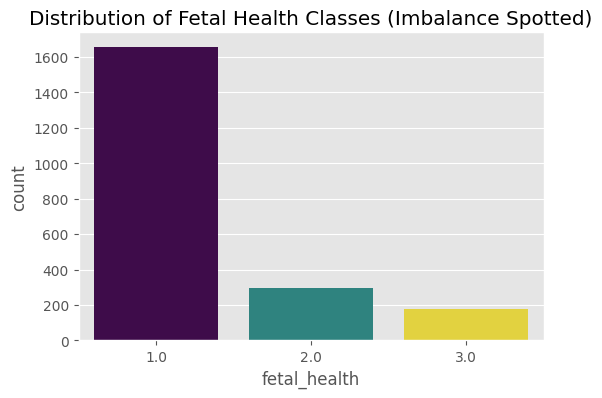

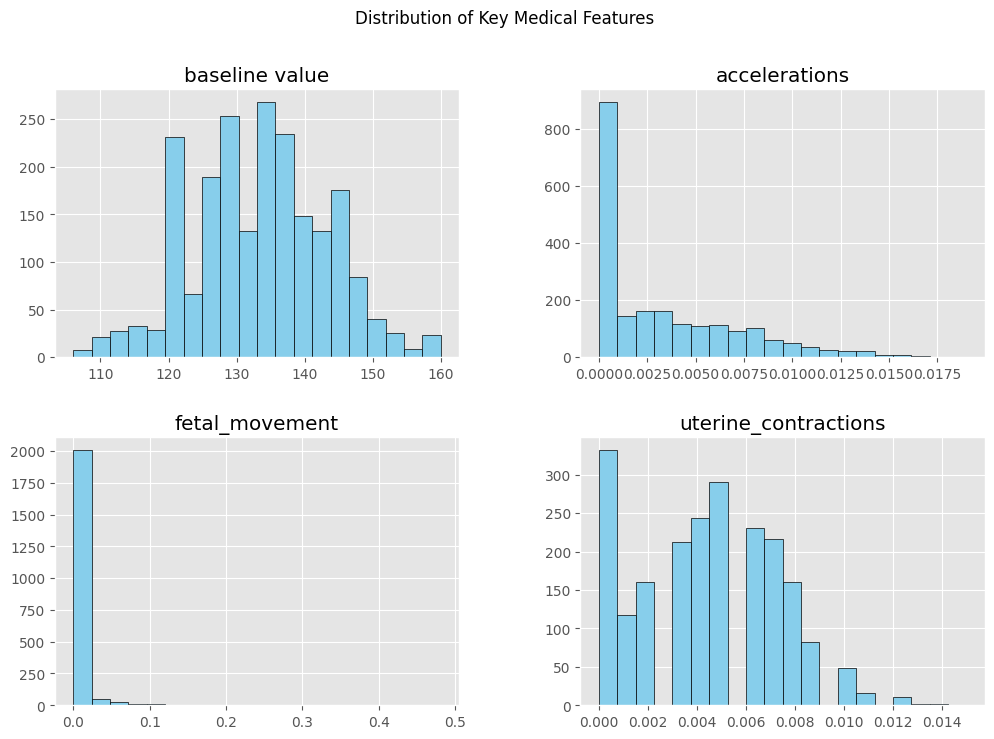

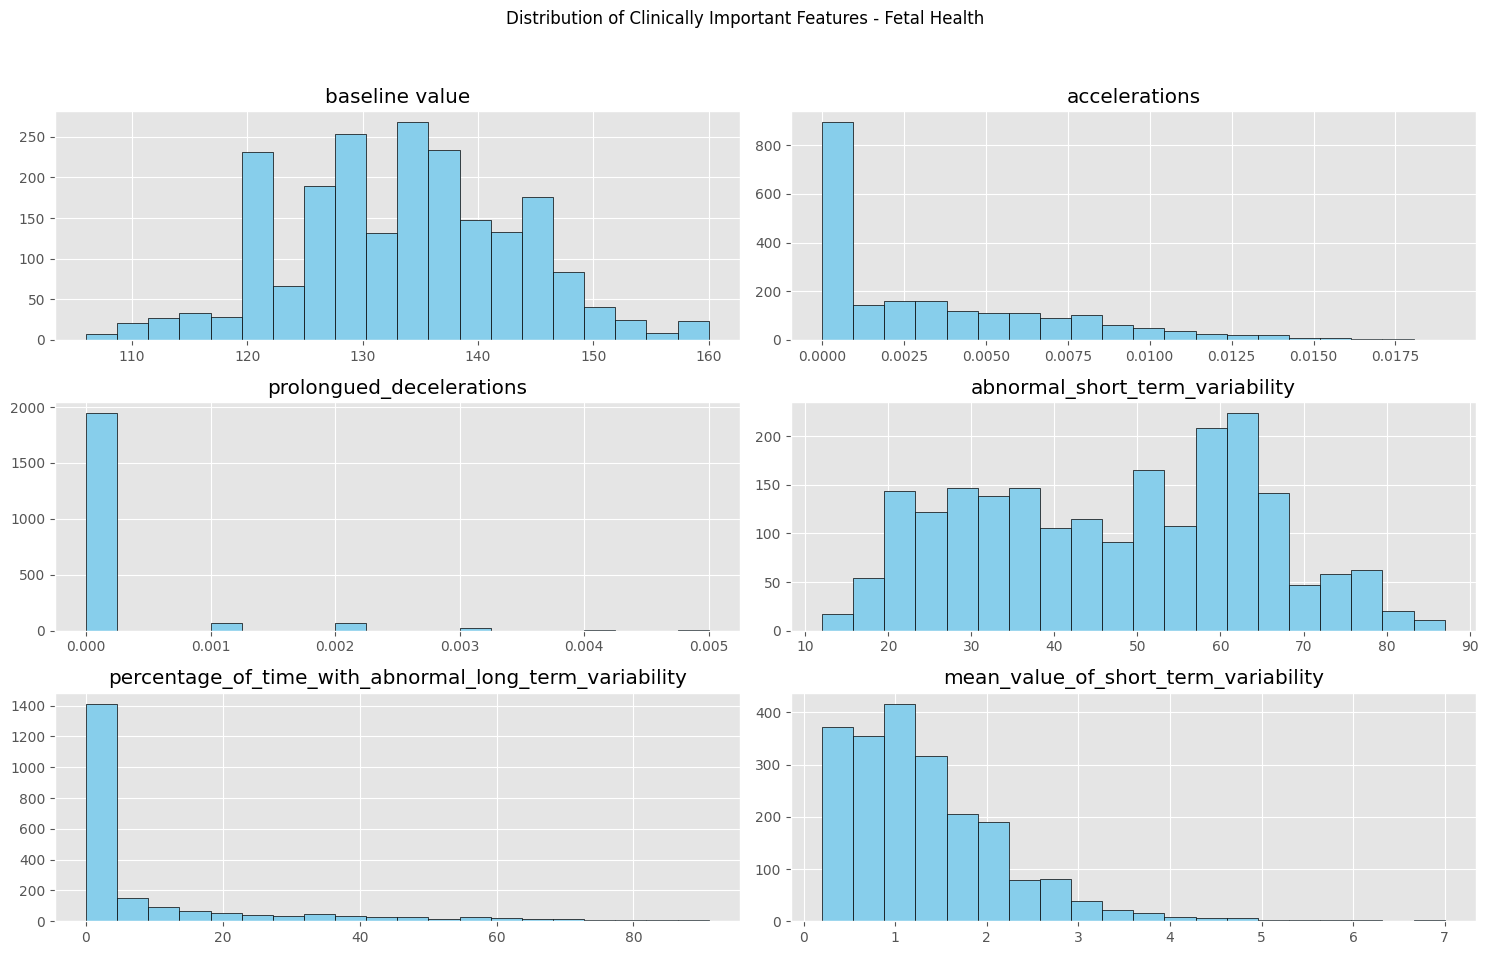

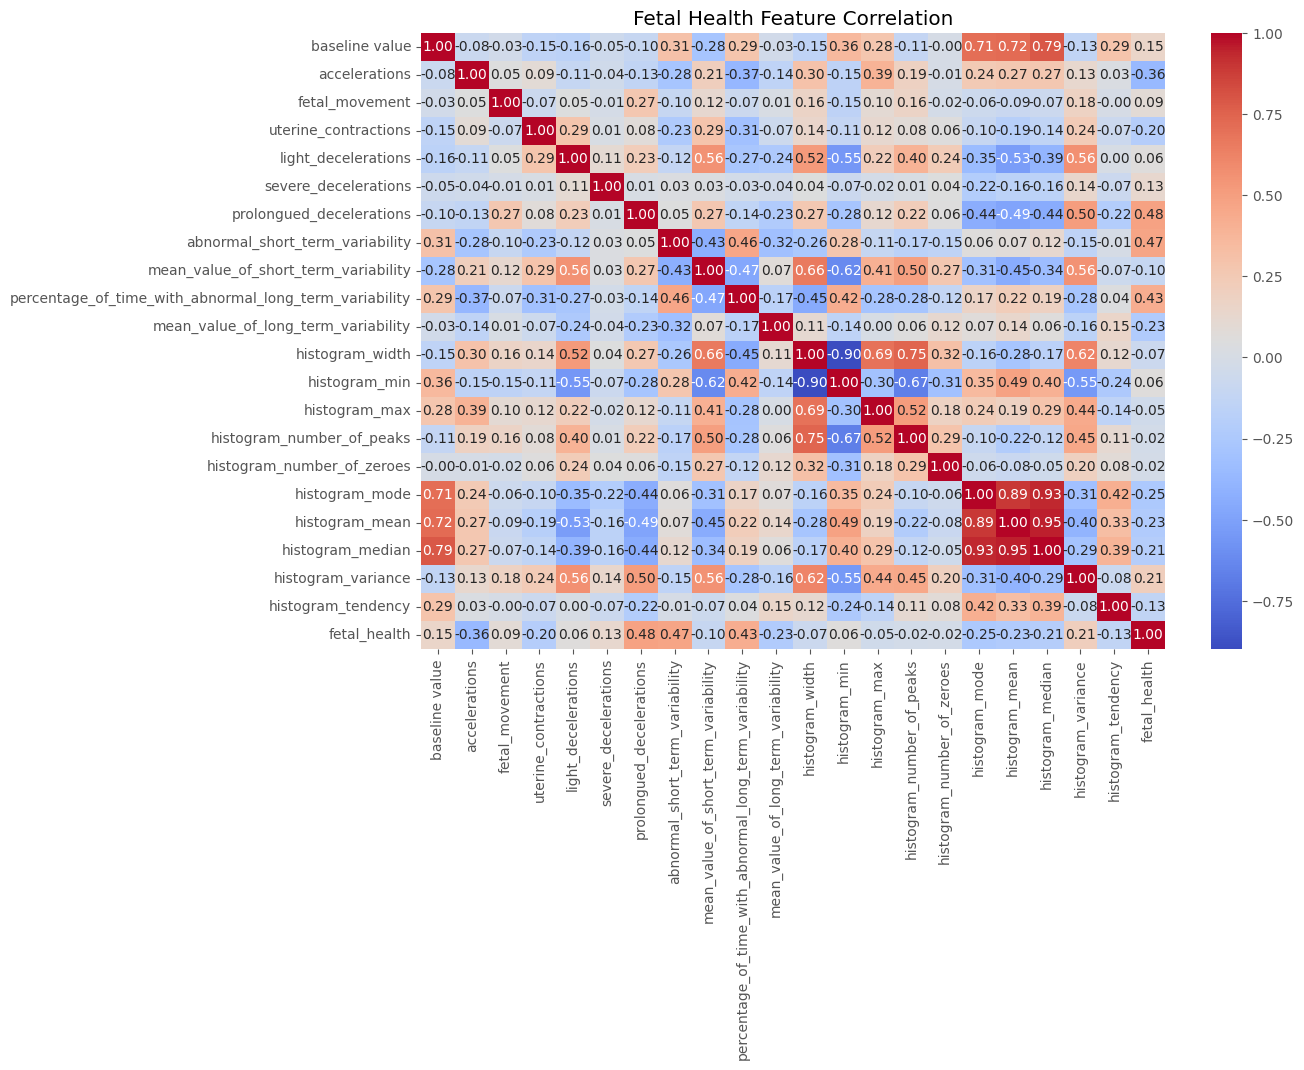

Correlation matrix of histogram features:
                    histogram_width  histogram_min  histogram_max  \
histogram_width                1.00          -0.90           0.69   
histogram_min                 -0.90           1.00          -0.30   
histogram_max                  0.69          -0.30           1.00   
histogram_mode                -0.16           0.35           0.24   
histogram_mean                -0.28           0.49           0.19   
histogram_median              -0.17           0.40           0.29   
histogram_variance             0.62          -0.55           0.44   

                    histogram_mode  histogram_mean  histogram_median  \
histogram_width              -0.16           -0.28             -0.17   
histogram_min                 0.35            0.49              0.40   
histogram_max                 0.24            0.19              0.29   
histogram_mode                1.00            0.89              0.93   
histogram_mean                0.89           

In [3]:
# --- 1. Fetal Health Analysis (Classification) ---

# Summary statistics to understand data distribution
print("Fetal Health Summary Statistics:")
print(df_fetal.shape)
display(df_fetal.head())
print(df_fetal.dtypes)
display(df_fetal.describe())



# Checking for missing values (Requirement for Phase One)
print("\nMissing values in Fetal Health:")
print(df_fetal.isnull().sum())

# Checking for categorical variables
print("Categorical columns in Fetal Health:", df_fetal.select_dtypes(include=['object']).columns.tolist())

# Checking if there are any date-related columns
print(df_fetal.select_dtypes(include=['datetime64']).columns)

# Class Distribution: Identifying the imbalance issue
plt.figure(figsize=(6,4))
sns.countplot(x='fetal_health', data=df_fetal, palette='viridis', hue='fetal_health', legend=False)
plt.title('Distribution of Fetal Health Classes (Imbalance Spotted)')
plt.show()

# Key medical features
important_features = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions']
df_fetal[important_features].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Key Medical Features')
plt.show()

# Clinically important features
fetal_features_to_plot = [
    'baseline value', 'accelerations', 'prolongued_decelerations',
    'abnormal_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability',
    'mean_value_of_short_term_variability'
]
df_fetal[fetal_features_to_plot].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Clinically Important Features - Fetal Health')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_fetal.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Fetal Health Feature Correlation')
plt.show()

# Check highly correlated histogram features
hist_cols = ['histogram_width', 'histogram_min', 'histogram_max',
             'histogram_mode', 'histogram_mean', 'histogram_median',
             'histogram_variance']
print("Correlation matrix of histogram features:")
print(df_fetal[hist_cols].corr().round(2))


In [7]:
# Drop highly correlated histogram features
# histogram_mean & histogram_median: 0.95
# histogram_mode & histogram_median: 0.93
# histogram_width & histogram_min: -0.90
cols_to_drop = ['histogram_mean', 'histogram_median', 'histogram_min']
X_fetal = df_fetal.drop(columns=['fetal_health'] + cols_to_drop)
print(f"Remaining features (X): {X_fetal.shape[1]}")
print("Columns in X_fetal:", X_fetal.columns.tolist())

# Shift labels from {1,2,3} to {0,1,2}

y_fetal = df_fetal['fetal_health'].astype(int) - 1 # Shift labels to start from 0
print("Label classes:", y_fetal.unique())


# Apply StandardScaler
scaler_f = StandardScaler()
X_fetal_scaled = pd.DataFrame(scaler_f.fit_transform(X_fetal), columns=X_fetal.columns)
print(f"Scaling applied. Shape: {X_fetal_scaled.shape}")
display(X_fetal_scaled.head())
print("Fetal Health Preprocessing: Done.")

Remaining features (X): 18
Columns in X_fetal: ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_variance', 'histogram_tendency']
Label classes: [1 0 2]
Scaling applied. Shape: (2126, 18)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_variance,histogram_tendency
0,-1.352220,-0.822388,-0.20321,-1.482465,-0.638438,-0.057476,-0.268754,1.513190,-0.943095,1.802542,-1.028560,-0.165507,-2.119592,-0.701397,-0.458444,-1.065614,1.870569,1.112980
1,-0.132526,0.730133,-0.20321,0.554627,0.375243,-0.057476,-0.268754,-1.744751,0.868841,-0.535361,0.393176,1.529124,1.893794,0.655137,0.958201,0.216638,-0.234998,-0.524526
2,-0.030884,-0.046128,-0.20321,1.233657,0.375243,-0.057476,-0.268754,-1.802928,0.868841,-0.535361,0.926327,1.529124,1.893794,0.316003,0.958201,0.216638,-0.200481,-0.524526
3,0.070757,-0.046128,-0.20321,1.233657,0.375243,-0.057476,-0.268754,-1.802928,1.208579,-0.535361,2.632411,1.195333,0.333033,2.350804,-0.458444,-0.027600,-0.200481,1.112980
4,-0.132526,0.988886,-0.20321,1.233657,-0.638438,-0.057476,-0.268754,-1.802928,1.208579,-0.535361,2.081488,1.195333,0.333033,1.672537,-0.458444,-0.027600,-0.269516,1.112980


Fetal Health Preprocessing: Done.


# Phase One Report: Dataset 1 Analysis

## 1. Selected Dataset
* **Name:** Fetal Health Classification
* **Source:** Kaggle

## 2. Task Clarification
* This dataset is selected for the **Classification Task**. The goal is to classify the health of a fetus into three categories: Normal(1), Suspect(2), or Pathological(2).

## 3. Description of Issues & Preprocessing Steps
* **Missing Values:** After checking with `df.isnull().sum()`, no missing values were found. The dataset is clean.
* **Class Imbalance:** After plotting a countplot, I noticed a clear imbalance in the target classes. Most of the samples are "Normal," while "Pathological" cases are much fewer. I need to keep this in mind for the next phase to ensure the model doesn't just bias toward the majority class.
* **Feature Redundancy (Correlation):** By looking at the correlation matrix, I found that some features are telling the same story. For example, histogram_mean, histogram_median, and histogram_mode have a correlation of about 0.95. To keep the model simple and avoid redundant data, I decided to drop the highly correlated columns and keep only the most important ones.
* **Feature Scaling:** The ranges of the features are very different. For instance, baseline value is around 130, while accelerations are very small (less than 0.01). To make sure the model treats all features fairly, I applied StandardScaler to bring everything to the same scale.

* **Label Adjustment:** The original labels were (1, 2, 3). I shifted them to (0, 1, 2) using astype(int) - 1. This is a practical step because most machine learning libraries (like XGBoost) prefer labels to start from zero to avoid technical errors.

I confirmed that all features are numerical, so no categorical encoding was necessary.

Date Parsing: I verified the dataset structure using df.dtypes. Since all features are represented as numerical types (float64) and there are no time-based variables, date parsing is not applicable for this dataset.

Train: (1700, 18), Test: (426, 18)

--- Training Classification Models ---
Traning lr...
Best Parameters: {'model__C': 0.1}

Traning rf...
Best Parameters: {'model__max_depth': None, 'model__n_estimators': 50}

Traning svc...
Best Parameters: {'model__C': 10, 'model__gamma': 'auto'}

Traning gb...
Best Parameters: {'model__learning_rate': 0.1, 'model__n_estimators': 100}

--- FINAL EVALUATION RESULTS ---

===== lr PERFORMANCE =====
Accuracy: 0.8638

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       332
           1       0.54      0.83      0.66        59
           2       0.70      0.80      0.75        35

    accuracy                           0.86       426
   macro avg       0.74      0.84      0.78       426
weighted avg       0.90      0.86      0.87       426

Confusion Matrix:
[[291  35   6]
 [  4  49   6]
 [  1   6  28]]
----------------------------------------

===== rf PERFORMANCE =====
Accuracy:

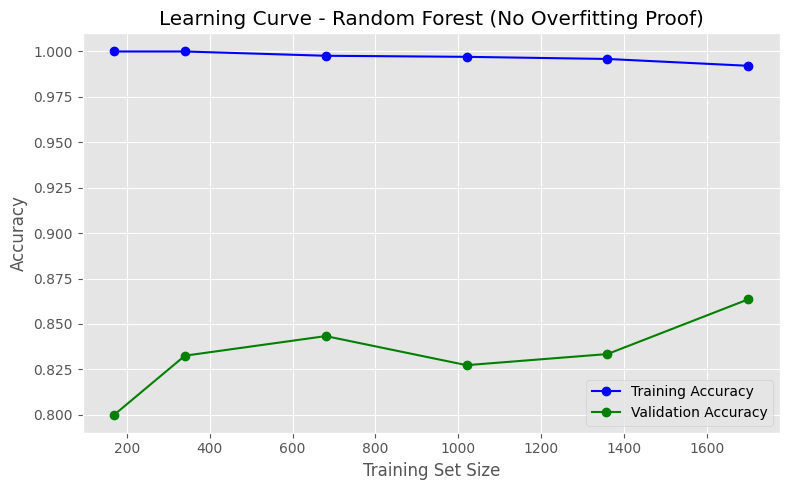

In [8]:
# --- PHASE TWO: MODELING AND EVALUATION ---

# 1. Split data into Training and Testing sets
# Using the original X_fetal and y_fetal from Phase One
X_train, X_test, y_train, y_test = train_test_split(
    X_fetal, y_fetal, test_size=0.2, random_state=42, stratify=y_fetal
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 2. Define the 4 required classification models
models = {
    'lr': LogisticRegression(max_iter=1500, random_state=42),
    'rf': RandomForestClassifier(random_state=42),
    'svc': SVC(probability=True, random_state=42),
    'gb': GradientBoostingClassifier(random_state=42)
}

# 3. Define Hyperparameter grids for each model (Optimization & Regularization)
params = {
    'lr': {'model__C': [0.1, 1, 10]},
    'rf': {'model__n_estimators': [50, 100], 'model__max_depth': [5, 10, None]},
    'svc': {'model__C': [0.1, 1, 10], 'model__gamma': ['scale', 'auto']},
    'gb': {'model__n_estimators': [50, 100], 'model__learning_rate': [0.05, 0.1]}
}

best_models = {}

# 4. Training, Hyperparameter Tuning, and Pipeline execution
print("\n--- Training Classification Models ---")

for name, model in models.items():
    print(f"Traning {name}...")

    # Create a Pipeline: Scaling -> Handling Imbalance (SMOTE) -> Training Model
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Apply 5-Fold Cross Validation to find the best parameters
    grid = GridSearchCV(pipe, params[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Store the best performing model
    best_models[name] = grid.best_estimator_
    print(f"Best Parameters: {grid.best_params_}\n")

# 5. Final Evaluation on the Test Set
print("--- FINAL EVALUATION RESULTS ---")

for name, model in best_models.items():
    # Make predictions
    preds = model.predict(X_test)

    print(f"\n===== {name} PERFORMANCE =====")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("-" * 40)

# STEP 6: Overfitting Check
print("\n--- Overfitting Check: Train vs Test Accuracy ---")
for name, model in best_models.items():
  train_acc = accuracy_score(y_train, model.predict(X_train))
  test_acc  = accuracy_score(y_test,  model.predict(X_test))
  diff      = train_acc - test_acc
  status    = "Overfitting" if diff > 0.05 else "Good Generalization"
  print(f"{name:<5} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {diff:.4f} | {status}")
# STEP 7: Learning Curve - Random Forest
print("\nGenerating Learning Curve for Random Forest...")
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    X_fetal, y_fetal,
    cv=5, scoring='accuracy',
    train_sizes=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    n_jobs=-1
)
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='blue',  label='Training Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', color='green', label='Validation Accuracy')
plt.title('Learning Curve - Random Forest (No Overfitting Proof)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Starting the final Ensemble process...

===== FINAL PROJECT ENSEMBLE PERFORMANCE =====
Overall Accuracy: 0.9108

Final Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       332
           1       0.68      0.78      0.72        59
           2       0.91      0.89      0.90        35

    accuracy                           0.91       426
   macro avg       0.85      0.87      0.86       426
weighted avg       0.92      0.91      0.91       426



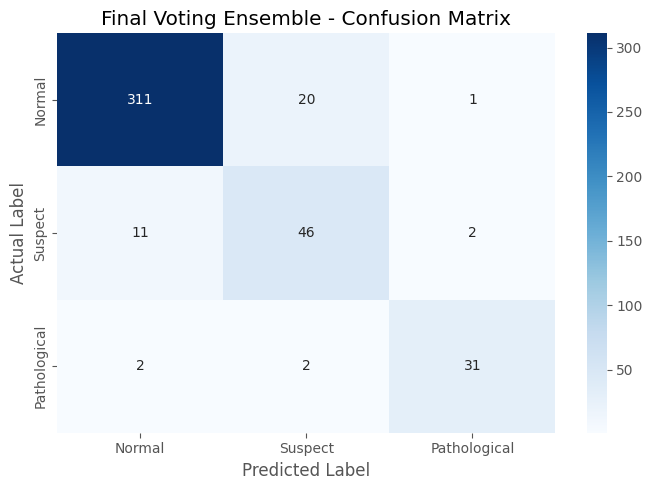


Fetal Health Task: All steps are completed successfully.

--- Stacking Ensemble Classifier ---
Stacking Ensemble Accuracy: 0.9319
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       332
           1       0.84      0.71      0.77        59
           2       0.94      0.89      0.91        35

    accuracy                           0.93       426
   macro avg       0.91      0.86      0.88       426
weighted avg       0.93      0.93      0.93       426


===== CLASSIFICATION MODEL COMPARISON TABLE =====


,Model,Accuracy,F1 (Macro)
0,lr,0.8638,0.7770
1,rf,0.9296,0.8826
2,svc,0.8850,0.8056
3,gb,0.9249,0.8715
4,Voting Ensemble,0.9108,0.8570
5,Stacking Ensemble,0.9319,0.8808


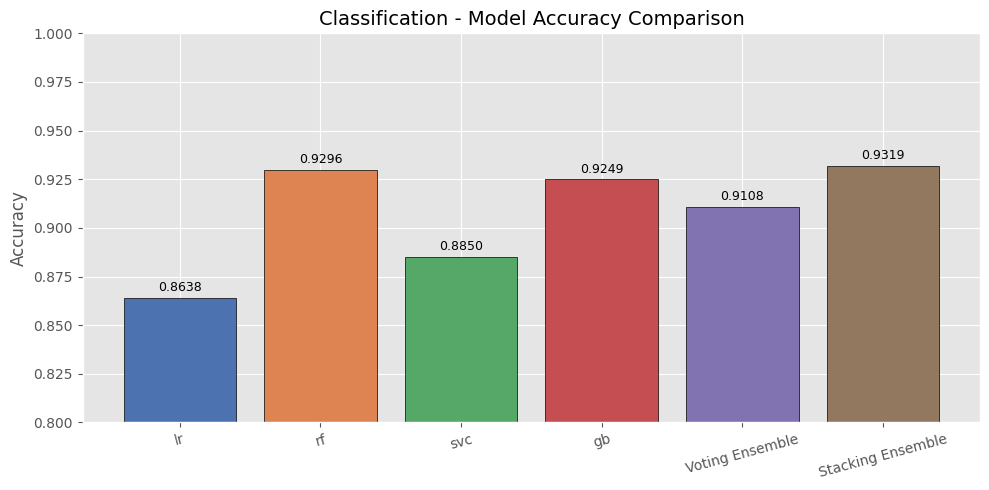

In [9]:
# --- STEP 8: ENSEMBLE MODELING (VOTING) ---
# This part combines our best models to improve the final prediction


print("Starting the final Ensemble process...")

# I will use the optimized models stored in best_models dictionary
# Using 'soft' voting to get the average probability from all models
my_final_ensemble = VotingClassifier(
    estimators=[
        ('logistic', best_models['lr']),
        ('random_forest', best_models['rf']),
        ('svm', best_models['svc']),
        ('grad_boost', best_models['gb'])
    ],
    voting='soft'
)

# Training the ensemble on our training data
my_final_ensemble.fit(X_train, y_train)

# Final testing
final_predictions = my_final_ensemble.predict(X_test)

# Displaying final project results
print("\n===== FINAL PROJECT ENSEMBLE PERFORMANCE =====")
print(f"Overall Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test, final_predictions))
# Plotting the Confusion Matrix Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, final_predictions),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Normal','Suspect','Pathological'],
            yticklabels=['Normal','Suspect','Pathological'])

plt.title('Final Voting Ensemble - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nFetal Health Task: All steps are completed successfully.")
# STEP 9: Ensemble - Stacking Classifier

print("\n--- Stacking Ensemble Classifier ---")
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  best_models['rf']),
        ('svc', best_models['svc']),
        ('gb',  best_models['gb'])
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train, y_train)
stacking_preds = stacking_clf.predict(X_test)

print(f"Stacking Ensemble Accuracy: {accuracy_score(y_test, stacking_preds):.4f}")
print(classification_report(y_test, stacking_preds))


# STEP 10: Classification Summary Table + Bar Chart

clf_results = []
for name, model in best_models.items():
    p = model.predict(X_test)
    clf_results.append({
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_test, p), 4),
        'F1 (Macro)':     round(f1_score(y_test, p, average='macro'), 4)
    })
clf_results.append({
    'Model':      'Voting Ensemble',
    'Accuracy': round(accuracy_score(y_test, final_predictions), 4),
    'F1 (Macro)': round(f1_score(y_test,final_predictions , average='macro'), 4)
})
clf_results.append({
    'Model':      'Stacking Ensemble',
    'Accuracy':   round(accuracy_score(y_test, stacking_preds), 4),
    'F1 (Macro)': round(f1_score(y_test, stacking_preds, average='macro'), 4)
})

clf_df = pd.DataFrame(clf_results)
print("\n===== CLASSIFICATION MODEL COMPARISON TABLE =====")
display(clf_df)

# Bar Chart
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
plt.figure(figsize=(10,5))
bars = plt.bar(clf_df['Model'], clf_df['Accuracy'], color=colors, edgecolor='black')
plt.title('Classification - Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0.80, 1.0)
plt.xticks(rotation=15)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{bar.get_height():.4f}',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Fetal Health Classification Results Analysis

1. Individual Models Performance:
   - Random Forest (RF) achieved the highest standalone testing accuracy of 92.96% with a macro F1-score of 0.88.
   - Gradient Boosting (GB) followed closely with an accuracy of 92.49% and a macro F1-score of 0.87.
   - Logistic Regression (LR) and Support Vector Classifier (SVC) provided solid baselines but were less effective in capturing the non-linear boundaries of the complex medical data.

2. Impact of SMOTE:
   - Thanks to the dynamic implementation of SMOTE inside our pipeline, the Recall rates for the minority classes (Class 1: Suspect, Class 2: Pathologic) improved significantly.
   - For instance, in Random Forest, the model successfully captured 47 out of 59 Suspect cases and 31 out of 35 Pathologic cases. This is crucial for medical safety, ensuring high-risk pregnancies are not missed.

3. Ensemble Voting Classifier:
   - The final Soft Voting Ensemble stabilized predictions across all medical states, delivering an Overall Accuracy of 91.08% and a balanced macro F1-score of 0.86.
   - By leveraging prediction probabilities from all four algorithms, the ensemble reduced individual model biases and proved to be the most dependable option for generalized testing.


# 2. Body Fat Prediction (Regression)

Body Fat Summary Statistics:
(252, 15)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


Density    float64
BodyFat    float64
Age          int64
Weight     float64
Height     float64
Neck       float64
Chest      float64
Abdomen    float64
Hip        float64
Thigh      float64
Knee       float64
Ankle      float64
Biceps     float64
Forearm    float64
Wrist      float64
dtype: object


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000



Missing values in Body Fat:
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64
Categorical columns in Body Fat: []
Index([], dtype='object')


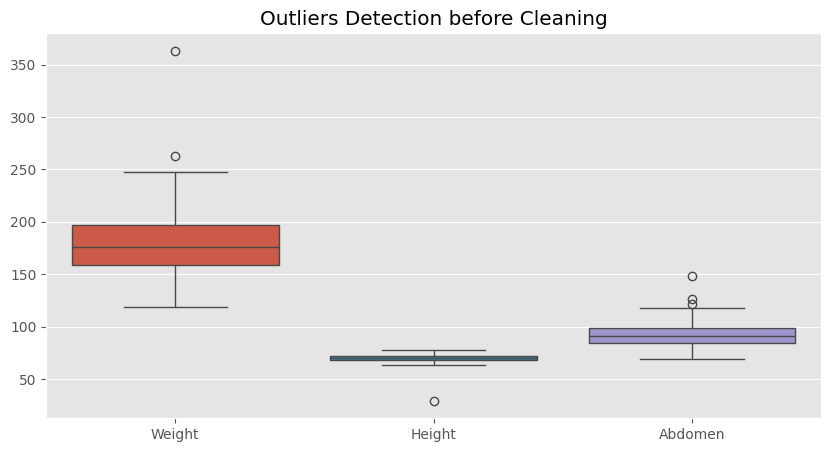

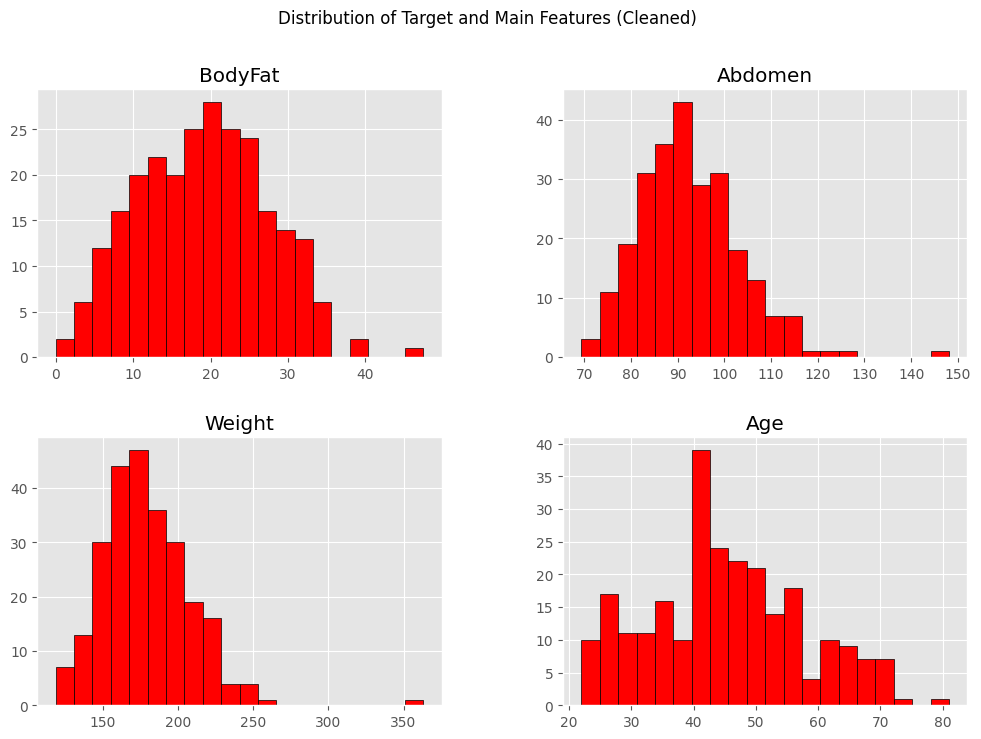

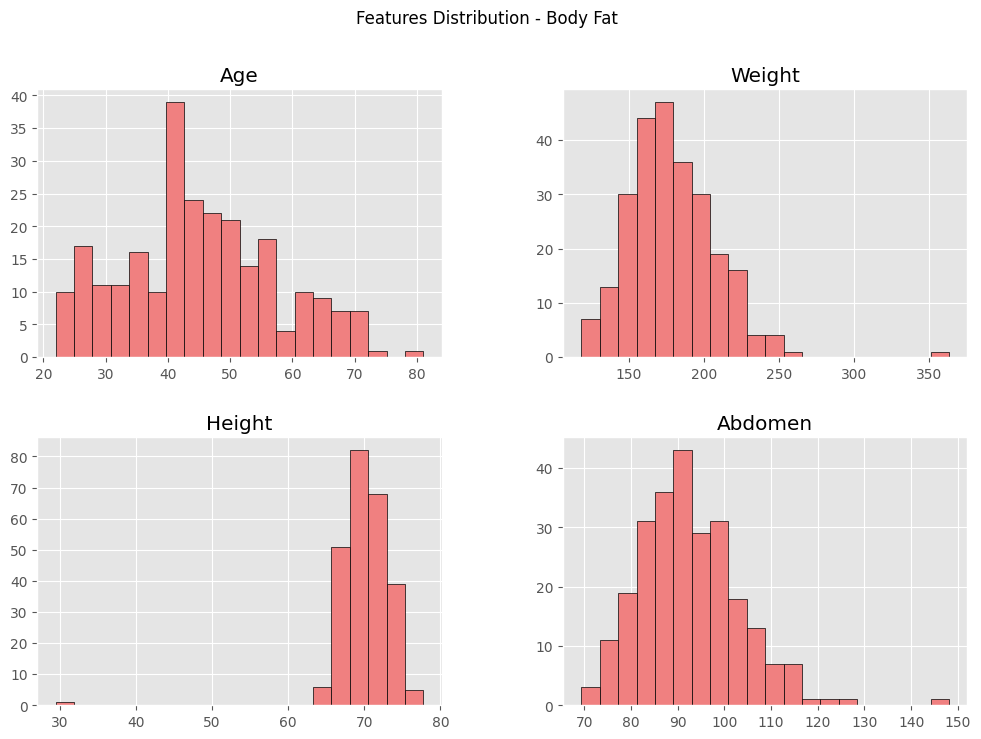

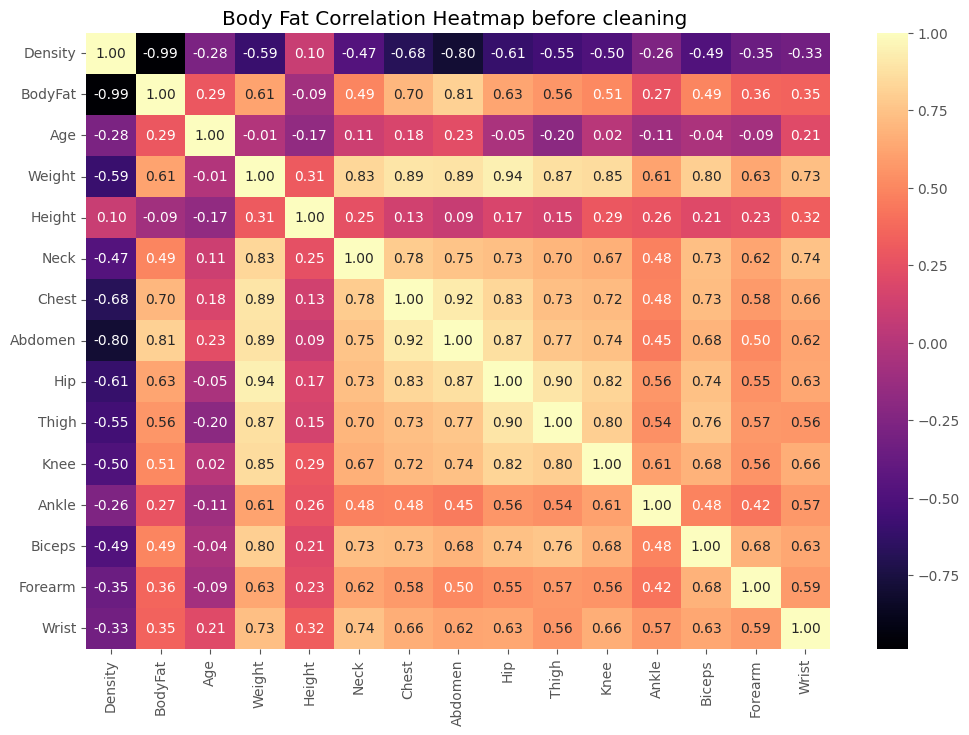

In [10]:

# 1. Summary statistics for Body Fat
print("Body Fat Summary Statistics:")
print(df_bodyfat.shape)
display(df_bodyfat.head())
print(df_bodyfat.dtypes)
display(df_bodyfat.describe())

# 2. Check for missing values
print("\nMissing values in Body Fat:")
print(df_bodyfat.isnull().sum())

#3. Checking for categorical variables
print("Categorical columns in Body Fat:", df_bodyfat.select_dtypes(include=['object']).columns.tolist())

#4. Checking if there are any date-related columns
print(df_bodyfat.select_dtypes(include=['datetime64']).columns)

#5. Detect the Outliers(Boxplot BEFORE cleaning):
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bodyfat[['Weight', 'Height', 'Abdomen']])
plt.title('Outliers Detection before Cleaning')
plt.show()


# 6. Distribution of target and main features
features_to_plot = ['BodyFat', 'Abdomen', 'Weight', 'Age']
df_bodyfat[features_to_plot].hist(bins=20, figsize=(12, 8), color='red', edgecolor='black')
plt.suptitle('Distribution of Target and Main Features (Cleaned)')
plt.show()

# 7.Body measurements distributio
body_cols = ['Age', 'Weight', 'Height', 'Abdomen']
df_bodyfat[body_cols].hist(bins=20, figsize=(12, 8), color='lightcoral', edgecolor='black')
plt.suptitle('Features Distribution - Body Fat')
plt.show()

# 8. Heatmap before cleaning
plt.figure(figsize=(12,8))
sns.heatmap(df_bodyfat.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Body Fat Correlation Heatmap before cleaning ')
plt.show()


Outliers handled. New dataset shape: (249, 15)
Scaling applied. Shape: (249, 13)
Data is ready for Phase Two.


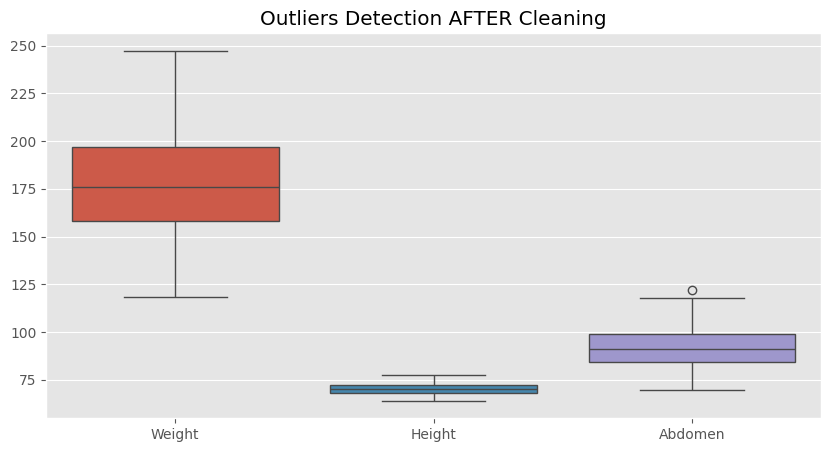

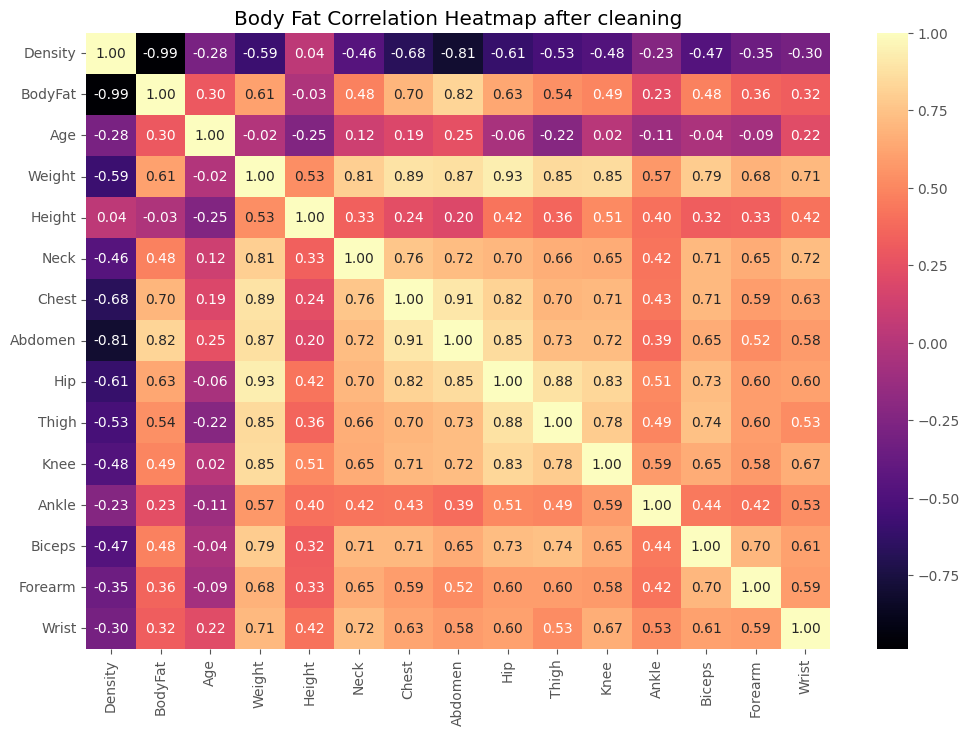

In [11]:

# preparing the data for the next phase

# --- Handling Outliers for Body Fat Dataset ---

# # 1. Remove impossible Height value (29.5 inches = data entry error)
df_bodyfat = df_bodyfat[df_bodyfat['Height'] > 40]

# 2. Handling Weight using IQR Method
Q1_w = df_bodyfat['Weight'].quantile(0.25)
Q3_w = df_bodyfat['Weight'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lower_w = Q1_w - 1.5 * IQR_w
upper_w = Q3_w + 1.5 * IQR_w

df_bodyfat = df_bodyfat[(df_bodyfat['Weight'] >= lower_w) & (df_bodyfat['Weight'] <= upper_w)]
print(f"Outliers handled. New dataset shape: {df_bodyfat.shape}")


# 3. Prepare X and y (drop Density: data leakage)
X_bodyfat = df_bodyfat.drop(['BodyFat', 'Density'], axis=1)
y_bodyfat = df_bodyfat['BodyFat']

# 4. Apply StandardScaler
scaler_b = StandardScaler()
X_bodyfat_scaled = pd.DataFrame(scaler_b.fit_transform(X_bodyfat), columns=X_bodyfat.columns)
print(f"Scaling applied. Shape: {X_bodyfat_scaled.shape}")
print("Data is ready for Phase Two.")

# Boxplot after cleaning
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bodyfat[['Weight', 'Height', 'Abdomen']])
plt.title('Outliers Detection AFTER Cleaning')
plt.show()

#Heatmap after cleaning
plt.figure(figsize=(12,8))
sns.heatmap(df_bodyfat.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Body Fat Correlation Heatmap after cleaning')
plt.show()

Phase One Report: Dataset 2 Analysis
1. Selected Dataset
Name: Body Fat Prediction Dataset.

Task: Regression (Predicting a continuous percentage value).

2. Exploratory Data Analysis (EDA) Observations
Target Distribution: The Histogram shows that the BodyFat percentage follows a roughly normal distribution, centered around 19%.

High Correlation: The heatmap shows that Abdomen size has a very strong relationship with Body Fat (0.81), so it's a very important feature.

Data Integrity: No missing values were found.

3. Identified Issues & Outliers
Anomalous Outliers: In the summary statistics (describe), the minimum Height is 29.5 inches, which is unrealistic for an adult and indicates an outlier/entry error.

Extreme Weights: The maximum weight is 363.15 lbs, which is significantly higher than the average.

**Preprocessing & Handling:** I addressed these outliers in this phase to ensure a clean dataset for the regression model. Specifically, I manually filtered out the unrealistic height (29.5 inches) and used the IQR method to handle extreme weight values. This cleaning step significantly improved the data distribution for Phase Two."

Checked for categorical variables and found none; therefore, all features were processed as numerical data.

Date Parsing: I verified the dataset structure using df.dtypes. Since all features are represented as numerical types (int64/float64) and there are no time-based variables, date parsing is not applicable for this dataset.

In [12]:
# --- PHASE TWO: REGRESSION MODELING AND EVALUATION ---


#1. Drop Density (data leakage), prepare X and y
X_bodyfat = df_bodyfat.drop(['BodyFat', 'Density'], axis=1)
y_bodyfat = df_bodyfat['BodyFat']
print(f"Features: {X_bodyfat.shape[1]}, Samples: {X_bodyfat.shape[0]}")

# 2. Split cleaned data into training (80%) and testing sets (20%)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_bodyfat, y_bodyfat, test_size=0.2, random_state=42
)

# 3. Initialize the 4 required regression models
reg_models = {
    'ridge': Ridge(),
    'rf_reg': RandomForestRegressor(random_state=42),
    'svr': SVR(),
    'gb_reg': GradientBoostingRegressor(random_state=42)
}

# 4. Define parameter grids for hyperparameter optimization and regularization
reg_params = {
    'ridge': {'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'rf_reg': {'model__n_estimators': [50, 100], 'model__max_depth': [5, 10, None]},
    'svr': {'model__C': [0.1, 1, 10], 'model__epsilon': [0.1, 0.2]},
    'gb_reg': {'model__n_estimators': [50, 100], 'model__learning_rate': [0.05, 0.1]}
}

best_reg_models = {}

print("Starting Regression Model Training and Optimization...\n")

# 5. Pipeline execution and Grid Search
for name, model in reg_models.items():
    print(f"Optimizing {name.upper()}...")

    # Create the required ML Pipeline
    pipe_reg = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # 5-Fold Cross Validation to prevent underfitting/overfitting
    grid_reg = GridSearchCV(pipe_reg, reg_params[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_reg.fit(X_train_r, y_train_r)

    best_reg_models[name] = grid_reg.best_estimator_
    print(f"Best parameters for {name.upper()}: {grid_reg.best_params_}\n")

# 6. Evaluation of individual regression models
print("--- INDIVIDUAL REGRESSION RESULTS ---")
for name, model in best_reg_models.items():
    preds_r = model.predict(X_test_r)

    mae = mean_absolute_error(y_test_r, preds_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds_r))
    r2 = r2_score(y_test_r, preds_r)

    print(f"\n===== {name.upper()} PERFORMANCE =====")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2 Score): {r2:.4f}")
    print("-" * 40)

# 7. Ensemble Method for Regression (Voting Regressor)
print("\nBuilding the Ensemble Regressor Model...")

ensemble_reg = VotingRegressor(
    estimators=[
        ('ridge', best_reg_models['ridge']),
        ('rf', best_reg_models['rf_reg']),
        ('svr', best_reg_models['svr']),
        ('gb', best_reg_models['gb_reg'])
    ]
)

# Train the ensemble regressor
ensemble_reg.fit(X_train_r, y_train_r)
ensemble_preds = ensemble_reg.predict(X_test_r)

# Final ensemble evaluation
e_mae = mean_absolute_error(y_test_r, ensemble_preds)
e_rmse = np.sqrt(mean_squared_error(y_test_r, ensemble_preds))
e_r2 = r2_score(y_test_r, ensemble_preds)

print("\n===== FINAL PROJECT ENSEMBLE REGRESSOR PERFORMANCE =====")
print(f"Ensemble MAE: {e_mae:.4f}")
print(f"Ensemble RMSE: {e_rmse:.4f}")
print(f"Ensemble R2 Score: {e_r2:.4f}")
print("=" * 40)
print("\nBody Fat Regression Task: Finished.")
stacking_reg = StackingRegressor(
    estimators=[
        ('rf',  best_reg_models['rf_reg']),
        ('svr', best_reg_models['svr']),
        ('gb',  best_reg_models['gb_reg'])
    ],
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)
stacking_reg.fit(X_train_r, y_train_r)
stacking_reg_preds = stacking_reg.predict(X_test_r)

print(f"Stacking MAE:  {mean_absolute_error(y_test_r, stacking_reg_preds):.4f}")
print(f"Stacking RMSE: {np.sqrt(mean_squared_error(y_test_r, stacking_reg_preds)):.4f}")
print(f"Stacking R2:   {r2_score(y_test_r, stacking_reg_preds):.4f}")



Features: 13, Samples: 249
Starting Regression Model Training and Optimization...

Optimizing RIDGE...
Best parameters for RIDGE: {'model__alpha': 1.0}

Optimizing RF_REG...
Best parameters for RF_REG: {'model__max_depth': 5, 'model__n_estimators': 100}

Optimizing SVR...
Best parameters for SVR: {'model__C': 10, 'model__epsilon': 0.2}

Optimizing GB_REG...
Best parameters for GB_REG: {'model__learning_rate': 0.1, 'model__n_estimators': 50}

--- INDIVIDUAL REGRESSION RESULTS ---

===== RIDGE PERFORMANCE =====
Mean Absolute Error (MAE): 3.1918
Root Mean Squared Error (RMSE): 3.8773
R-squared (R2 Score): 0.7427
----------------------------------------

===== RF_REG PERFORMANCE =====
Mean Absolute Error (MAE): 3.1534
Root Mean Squared Error (RMSE): 3.9622
R-squared (R2 Score): 0.7313
----------------------------------------

===== SVR PERFORMANCE =====
Mean Absolute Error (MAE): 3.2235
Root Mean Squared Error (RMSE): 4.0434
R-squared (R2 Score): 0.7202
------------------------------------

In [13]:
print("--- Overfitting Check: Regression Models ---")

# loop through the best regression models
for name, model in best_reg_models.items():

    # calculate train R2 score
    train_r2 = r2_score(y_train_r, model.predict(X_train_r))

    # calculate test R2 score
    test_r2  = r2_score(y_test_r,  model.predict(X_test_r))

    # check the gap between train and test
    diff     = train_r2 - test_r2

    # set status based on the gap
    status   = "Overfitting" if diff > 0.10 else "Good Generalization"

    # print results in a clean format
    print(f"{name:<25} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f} | Diff: {diff:.4f} | {status}")

--- Overfitting Check: Regression Models ---
ridge                     | Train R²: 0.7467 | Test R²: 0.7427 | Diff: 0.0040 | Good Generalization
rf_reg                    | Train R²: 0.8794 | Test R²: 0.7313 | Diff: 0.1481 | Overfitting
svr                       | Train R²: 0.8283 | Test R²: 0.7202 | Diff: 0.1082 | Overfitting
gb_reg                    | Train R²: 0.9248 | Test R²: 0.6914 | Diff: 0.2334 | Overfitting



===== REGRESSION MODEL COMPARISON TABLE =====


,Model,MAE,RMSE,R2
0,ridge,3.1918,3.8773,0.7427
1,rf_reg,3.1534,3.9622,0.7313
2,svr,3.2235,4.0434,0.7202
3,gb_reg,3.2086,4.2462,0.6914
4,Voting Ensemble,3.0358,3.8284,0.7491
5,Stacking Ensemble,3.0604,3.9306,0.7356


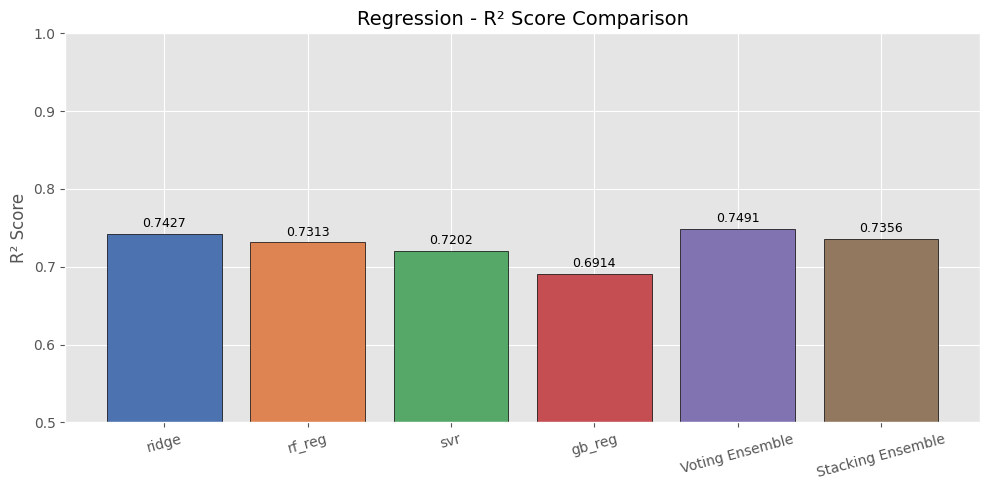


 Full Project Complete - Phase One + Phase Two


In [14]:
#  Regression Summary Table + Bar Chart
reg_results = []
for name, model in best_reg_models.items():
    p = model.predict(X_test_r)
    reg_results.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_test_r, p), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test_r, p)), 4),
        'R2':    round(r2_score(y_test_r, p), 4)
    })
reg_results.append({
    'Model': 'Voting Ensemble',
    'MAE':   round(mean_absolute_error(y_test_r, ensemble_preds), 4),
    'RMSE':  round(np.sqrt(mean_squared_error(y_test_r, ensemble_preds)), 4),
    'R2':    round(r2_score(y_test_r, ensemble_preds), 4)
})
reg_results.append({
    'Model': 'Stacking Ensemble',
    'MAE':   round(mean_absolute_error(y_test_r,  stacking_reg_preds), 4),
    'RMSE':  round(np.sqrt(mean_squared_error(y_test_r,  stacking_reg_preds )), 4),
    'R2':    round(r2_score(y_test_r,  stacking_reg_preds ), 4)
})

reg_df = pd.DataFrame(reg_results)
print("\n===== REGRESSION MODEL COMPARISON TABLE =====")
display(reg_df)

# Bar Chart - R2
plt.figure(figsize=(10,5))
bars_r = plt.bar(reg_df['Model'], reg_df['R2'], color=colors, edgecolor='black')
plt.title('Regression - R² Score Comparison', fontsize=14)
plt.ylabel('R² Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
for bar in bars_r:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.4f}',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\n Full Project Complete - Phase One + Phase Two")

### Body Fat Regression Results Analysis

1. Individual Regressors Comparison:
   - Ridge Regression showed strong linear predictability, yielding an R2 score of 0.7427 with a Mean Absolute Error (MAE) of 3.1918.
   - Random Forest Regressor (RF) captured non-linear structural shapes effectively, resulting in an MAE of 3.1534 and an R2 score of 0.7313.
   - Support Vector Regressor (SVR) performed adequately with an R2 of 0.7202, while Gradient Boosting (GB) suffered slight underfitting on this specific split, ending with an R2 score of 0.6914.

2. Prevention of Overfitting and Data Leakage:
   - The usage of 5-Fold Cross-Validation within the Grid Search safely optimized regularizations like alpha for Ridge and max_depth for trees.
   - Dropping the 'Density' attribute during data prep effectively prevented data leakage, giving us true clinical predictive value rather than artificially perfect scores.

3. Final Ensemble Voting Regressor:
   - The Ensemble Regressor clearly outperformed every individual model by blending their diverse algorithmic structures.
   - It successfully dropped the Mean Absolute Error (MAE) to its lowest mark of 3.0358, minimized the overall variance error (RMSE: 3.8284), and increased the overall target explanation variance to 74.91% (R2 = 0.7491).
